### create baseline model: random forest regressor

In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [53]:
PROCESSED_PATH = Path("../data/processed/rolling_sample.parquet")

df_rolling = pd.read_parquet(PROCESSED_PATH)
df_rolling['datetime'] = df_rolling['datetime'].sort_values(ascending=True)
print(df_rolling.shape)
df_rolling.head()

(2136, 28)


,datetime,dt,hour,demand,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
0,2024-03-29 00:00:00,2024-03-29,0,8.2,2.0,8.3,10.5,14.5,23.25,27.80,...,91.1,85.0,62.8,32.9,9.7,2.7,1.6,1.6,4.2,9.7
1,2024-03-29 01:00:00,2024-03-29,1,4.9,8.2,2.0,8.3,10.5,14.50,23.25,...,76.7,91.1,85.0,62.8,32.9,9.7,2.7,1.6,1.6,4.2
2,2024-03-29 02:00:00,2024-03-29,2,2.1,4.9,8.2,2.0,8.3,10.50,14.50,...,48.9,76.7,91.1,85.0,62.8,32.9,9.7,2.7,1.6,1.6
3,2024-03-29 03:00:00,2024-03-29,3,2.5,2.1,4.9,8.2,2.0,8.30,10.50,...,48.7,48.9,76.7,91.1,85.0,62.8,32.9,9.7,2.7,1.6
4,2024-03-29 04:00:00,2024-03-29,4,3.4,2.5,2.1,4.9,8.2,2.00,8.30,...,49.0,48.7,48.9,76.7,91.1,85.0,62.8,32.9,9.7,2.7


In [54]:
df_rolling.columns

Index(['datetime', 'dt', 'hour', 'demand', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
       'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11',
       'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18',
       'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24'],
      dtype='str')

In [55]:
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
       'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11',
       'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18',
       'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'hour'
]

X = df_rolling[feature_cols]
y = df_rolling["demand"]

In [56]:
train_size = int(len(df_rolling) * 0.8)

train_df = df_rolling.iloc[:train_size]
test_df = df_rolling.iloc[train_size:]

X_train = train_df[feature_cols]
y_train = train_df["demand"]

X_test = test_df[feature_cols]
y_test = test_df["demand"]

In [57]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [58]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 5.3469
RMSE: 8.0178


In [59]:
predictions = test_df[["datetime", "demand"]].copy()
predictions["prediction"] = y_pred
predictions["model"] = "random_forest"
predictions

,datetime,demand,prediction,model
1708,2024-06-08 04:00:00,6.30,5.4290,random_forest
1709,2024-06-08 05:00:00,19.20,18.1300,random_forest
1710,2024-06-08 06:00:00,54.50,48.8653,random_forest
1711,2024-06-08 07:00:00,90.70,88.0570,random_forest
1712,2024-06-08 08:00:00,153.00,122.4720,random_forest
...,...,...,...,...
2131,2024-06-25 19:00:00,40.37,37.4525,random_forest
2132,2024-06-25 20:00:00,32.70,27.7867,random_forest
2133,2024-06-25 21:00:00,17.70,21.0757,random_forest
2134,2024-06-25 22:00:00,15.70,16.0803,random_forest


In [60]:
PREDICTION_PATH = Path("../outputs/predictions/random_forest_predictions.parquet")
PREDICTION_PATH.parent.mkdir(parents=True, exist_ok=True)

predictions.to_parquet(PREDICTION_PATH, index=False)

In [61]:
metrics = pd.DataFrame([
    {
        "model": "random_forest",
        "mae": mae,
        "rmse": rmse,
    }
])

METRICS_PATH = Path("../outputs/evaluation/random_forest_metrics.csv")
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

metrics.to_csv(METRICS_PATH, index=False)

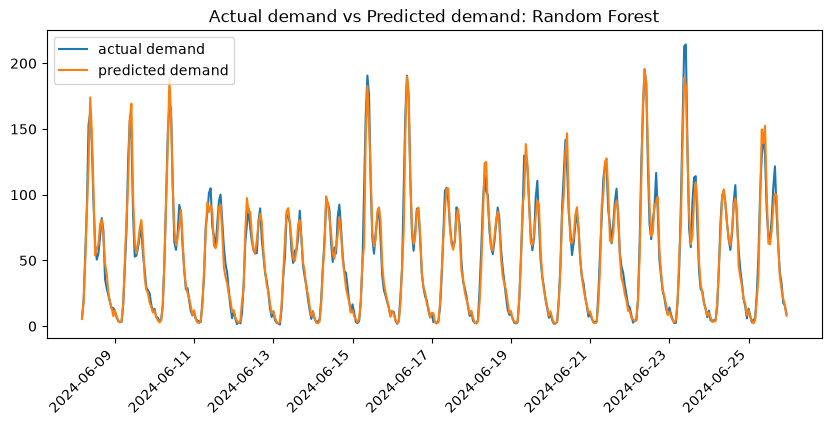

In [62]:
VIZ_PATH = Path("../outputs/figures")

plt.figure(figsize=(10, 4))
plt.plot(predictions['datetime'], predictions['demand'], label = "actual demand")
plt.plot(predictions['datetime'], predictions['prediction'], label = "predicted demand")
plt.xticks(rotation=45, ha='right') 
plt.legend()
plt.title("Actual demand vs Predicted demand: Random Forest")
plt.savefig(f'{VIZ_PATH}/act_vs_pred_rf.png')
plt.show()

### create baseline model: LSTM

The chronological order should be:

["lag_24", "lag_23", ..., "lag_2", "lag_1"]

Not:

["lag_1", "lag_2", ..., "lag_24"]

Because LSTM should read from oldest to newest

Flow:

1. Create X and y
2. Split train/test by time
3. Fit scaler only on train
4. Transform train and test
5. Convert to PyTorch tensors

In [63]:
lag_cols = [f"lag_{i}" for i in range(24, 0, -1)]

X = df_rolling[lag_cols].values
y = df_rolling['demand'].values

In [64]:
print(X.shape)
print(y.shape)

(2136, 24)
(2136,)


#### reshape 2D to 3D

**Since LSTM expects 3D input, we'll reshape**

X shape = (num_rows, num_cols, num_features)
X shape = (2136, 24, 1)

2136 samples

24 time steps per sample

1 feature per time step: demand

In [65]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(2136, 24, 1)


In [66]:
'''
X = [
  [demand_t-24],
  [demand_t-23],
  ...
  [demand_t-1]
]
'''

'''
y = demand_t
'''

sample_idx = 0

print("Input sequence:")
print(X[sample_idx].flatten())

print("Target:")
print(y[sample_idx])

Input sequence:
[ 9.7   4.2   1.6   1.6   2.7   9.7  32.9  62.8  85.   91.1  76.7  48.9
 48.7  49.   48.7  58.3  59.   39.5  27.8  23.25 14.5  10.5   8.3   2.  ]
Target:
8.200000000000001


In [67]:
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [68]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1708, 24, 1) (1708,)
(428, 24, 1) (428,)


X_train
= 3D LSTM input

reshape(-1, 1)
= temporarily flatten so StandardScaler can work

reshape(X_train.shape)
= restore LSTM format

In [69]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1,1))
X_train_scaled = X_train_scaled.reshape(X_train.shape)

X_test_scaled = scaler.transform(X_test.reshape(-1, 1))
X_test_scaled = X_test_scaled.reshape(X_test.shape)

In [70]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1708, 24, 1)
(428, 24, 1)


#### scale training set only

In [71]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

In [72]:
print(y_train_scaled.shape)
print(y_test_scaled.shape)

(1708, 1)
(428, 1)


#### convert to tensor

In [73]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

In [74]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)
print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([1708, 24, 1])
torch.Size([428, 24, 1])
torch.Size([1708, 1])
torch.Size([428, 1])


#### create TensorDataset -> DataLoader

TensorDataset = equivalent to (X, y) tuple in numpy/sklearn

In [75]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### build model flow

**1. Define LSTM model**

LSTM layer

    ↓

take final hidden output

    ↓

Linear layer

    ↓

prediction

In [76]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        prediction = self.fc(last_hidden)
        return prediction

**2. create model**

In [77]:
input_size = 1
hidden_size = 32
num_layers = 1
output_size = 1

model = LSTMForecaster(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=output_size
)

In [78]:
sample_X, sample_y = next(iter(train_loader))
sample_pred = model(sample_X)

print(sample_X.shape)
print(sample_pred.shape)

torch.Size([32, 24, 1])
torch.Size([32, 1])


**3. define loss & optimizer**

In [79]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

**4. training loop**

In [80]:
len(train_loader)

54

In [81]:
num_epochs = 50
for epoch in range(num_epochs): # for each epoch
    model.train() # set model to train mode
    train_loss = 0.0 # set train loss
    for X_batch, y_batch in train_loader: # for each batch
        y_pred = model(X_batch) # predict
        loss = loss_fn(y_pred, y_batch) # compute loss y_pred vs actual (y_batch)

        optimizer.zero_grad() # clear old gradients
        loss.backward() # backprop
        optimizer.step() # update weights

        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}")

Epoch [10/50], Loss: 0.0784
Epoch [20/50], Loss: 0.0371
Epoch [30/50], Loss: 0.0299
Epoch [40/50], Loss: 0.0262
Epoch [50/50], Loss: 0.0241


**5. prediction on test set**

In [82]:
model.eval()

predictions = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        y_pred = model(X_batch)
        predictions.append(y_pred)

y_pred_scaled = torch.cat(predictions).numpy()

In [83]:
y_pred_scaled.shape

(428, 1)

**6. inverse scale predictions**

convert predictions back to original demand scale

In [84]:
y_pred_original = y_scaler.inverse_transform(y_pred_scaled)
y_test_original = y_scaler.inverse_transform(y_test_scaled)

**7. evaluate mae/rmse**

In [85]:
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

print(f"LSTM MAE: {mae:.4f}")
print(f"LSTM RMSE: {rmse:.4f}")

LSTM MAE: 4.8696
LSTM RMSE: 6.7538


#### save predictions & dataframe

In [86]:
test_df = df_rolling.iloc[split_idx:].copy()

In [87]:
lstm_predictions = test_df[["datetime"]].copy()
lstm_predictions["demand"] = y_test_original.flatten()
lstm_predictions["prediction"] = y_pred_original.flatten()
lstm_predictions["model"] = "lstm_baseline"

In [88]:
lstm_predictions.info()

<class 'pandas.DataFrame'>
RangeIndex: 428 entries, 1708 to 2135
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    428 non-null    datetime64[us]
 1   demand      428 non-null    float64       
 2   prediction  428 non-null    float32       
 3   model       428 non-null    str           
dtypes: datetime64[us](1), float32(1), float64(1), str(1)
memory usage: 17.3 KB


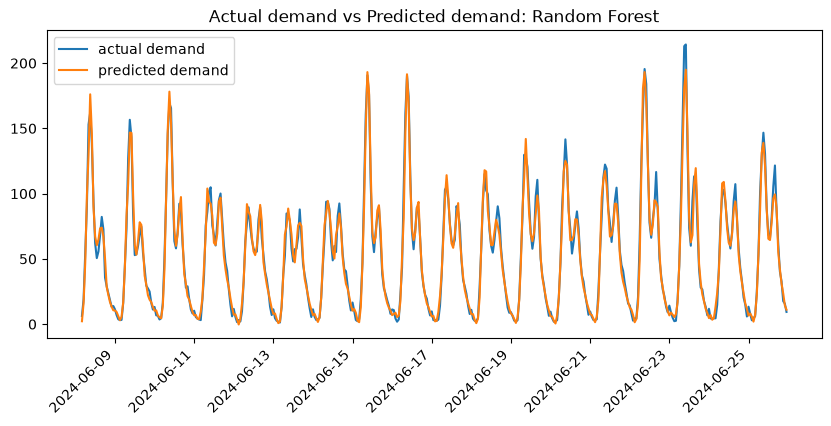

In [89]:
VIZ_PATH = Path("../outputs/figures")

plt.figure(figsize=(10, 4))
plt.plot(lstm_predictions['datetime'], lstm_predictions['demand'], label = "actual demand")
plt.plot(lstm_predictions['datetime'], lstm_predictions['prediction'], label = "predicted demand")
plt.xticks(rotation=45, ha='right') 
plt.legend()
plt.title("Actual demand vs Predicted demand: Random Forest")
plt.savefig(f'{VIZ_PATH}/act_vs_pred_lstm.png')
plt.show()

In [90]:
PRED_PATH = Path("../outputs/predictions/lstm_baseline_predictions.parquet")
PRED_PATH.parent.mkdir(parents=True, exist_ok=True)

lstm_predictions.to_parquet(PRED_PATH, index=False)

#### add metrics

In [46]:
metrics = pd.DataFrame([
    {
        "model": "lstm_baseline",
        "mae": mae,
        "rmse": rmse,
    }
])

METRICS_PATH = Path("../outputs/evaluation/lstm_baseline_metrics.csv")
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

metrics.to_csv(METRICS_PATH, index=False)